Выбор файла загрузки

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


Считывание датасета из файла train.csv

In [42]:
import pandas as pd
data = pd.read_csv('train.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Выбор и обоснование метрики для измерения качества

В файле train.csv присутствует много классов данных, причем эти классы несбалансированы: выживших пассажиров  меньше, чем погибших, так же как и женщин (результаты получены в предыдущих заданиях). Поэтому следует выбрать, например, метрику F1-score (особенно гармоническое среднее precision и recall). Использование accuracy может привести к завышенной оценке, так как большинство записей в столбце Survived - 0, и модель может всегда выдавать результат «погиб». Метрика F1-score позволяет получить более достоверную оценку, учитывая точность и полноту.

Предобработка данных

Преобразование столбца Sex: замена в столбце значений 'female' на 0, 'male' на 1.

In [43]:
data['Sex'].replace({'female': 0, 'male': 1}, inplace=True)
data.head()

/tmp/ipykernel_821/2760665789.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Sex'].replace({'female': 0, 'male': 1}, inplace=True)
/tmp/ipykernel_821/2760665789.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Sex'].replace({'female': 0, 'male': 1}, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


Заполнение пустых значений в Age средними значениями с учётом класса Pclass

In [44]:
data_new = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch']]

# Вычисляем среднее значение возраста для каждого класса Pclass
mean_age_by_pclass = data_new.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))

# Заполняем пустые значения в Age с учётом класса Pclass
data_new.loc[data_new['Age'].isnull(), 'Age'] = mean_age_by_pclass
print(data_new)

# Преобразование в список списков
data_new1 = data_new.values.tolist()
print(data_new1)

     Survived  Pclass  Sex       Age  SibSp  Parch
0           0       3    1  22.00000      1      0
1           1       1    0  38.00000      1      0
2           1       3    0  26.00000      0      0
3           1       1    0  35.00000      1      0
4           0       3    1  35.00000      0      0
..        ...     ...  ...       ...    ...    ...
886         0       2    1  27.00000      0      0
887         1       1    0  19.00000      0      0
888         0       3    0  25.14062      1      2
889         1       1    1  26.00000      0      0
890         0       3    1  32.00000      0      0

[891 rows x 6 columns]
[[0.0, 3.0, 1.0, 22.0, 1.0, 0.0], [1.0, 1.0, 0.0, 38.0, 1.0, 0.0], [1.0, 3.0, 0.0, 26.0, 0.0, 0.0], [1.0, 1.0, 0.0, 35.0, 1.0, 0.0], [0.0, 3.0, 1.0, 35.0, 0.0, 0.0], [0.0, 3.0, 1.0, 25.14061971830986, 0.0, 0.0], [0.0, 1.0, 1.0, 54.0, 0.0, 0.0], [0.0, 3.0, 1.0, 2.0, 3.0, 1.0], [1.0, 3.0, 0.0, 27.0, 0.0, 2.0], [1.0, 2.0, 0.0, 14.0, 1.0, 0.0], [1.0, 3.0, 0.0, 4.0, 

Разбиение датасета на тренировочную и тестовую выборки

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# 0 – "погибли", 1 – "выжили"
y = 1 - data_new['Survived']
X = data_new.drop(labels=['Survived'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=713, test_size=0.25)

Построение бейзлайна

In [46]:
from sklearn.metrics import accuracy_score

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

y_pred_dummy = dummy_clf.predict(X_test)
accuracy_score(y_test, y_pred_dummy)

0.6098654708520179

Построение ML-модели классификации

In [47]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_test)
accuracy_score(y_test, y_pred_log_reg)

0.8116591928251121

Метрики Precision и Recall

In [48]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
confusion_matrix(y_test, y_pred_dummy)

print(f'Precision for Dummy Classificator: {precision_score(y_test, y_pred_dummy, zero_division=0)}')
print(f'Precision for Logistic regression: {precision_score(y_test, y_pred_log_reg, zero_division=0)}')

confusion_matrix(y_test, y_pred_log_reg)

print(f'Recall for Dummy Classificator: {recall_score(y_test, y_pred_dummy)}')
print(f'Recall for Logistic regression: {recall_score(y_test, y_pred_log_reg)}')

Precision for Dummy Classificator: 0.6098654708520179
Precision for Logistic regression: 0.821917808219178
Recall for Dummy Classificator: 1.0
Recall for Logistic regression: 0.8823529411764706


F-мера

In [49]:
from sklearn.metrics import f1_score, fbeta_score

print(f'F1-score for Dummy Classificator: {f1_score(y_test, y_pred_dummy)}')
print(f'F1-score for Logistic regression: {f1_score(y_test, y_pred_log_reg)}')

print(f'Fbeta-score for Dummy Classificator (recall bias): {fbeta_score(y_test, y_pred_dummy, beta=2)}')
print(f'Fbeta-score for Logistic regression (recall bias): {fbeta_score(y_test, y_pred_log_reg, beta=2)}')

print(f'Fbeta-score for Dummy Classificator (precision bias): {fbeta_score(y_test, y_pred_dummy, beta=0.5)}')
print(f'Fbeta-score for Logistic regression (precision bias): {fbeta_score(y_test, y_pred_log_reg, beta=0.5)}')

F1-score for Dummy Classificator: 0.7576601671309192
F1-score for Logistic regression: 0.851063829787234
Fbeta-score for Dummy Classificator (recall bias): 0.8865710560625815
Fbeta-score for Logistic regression (recall bias): 0.8695652173913043
Fbeta-score for Dummy Classificator (precision bias): 0.6614785992217899
Fbeta-score for Logistic regression (precision bias): 0.8333333333333334


In [ ]:
Построение графика Precision-Recall

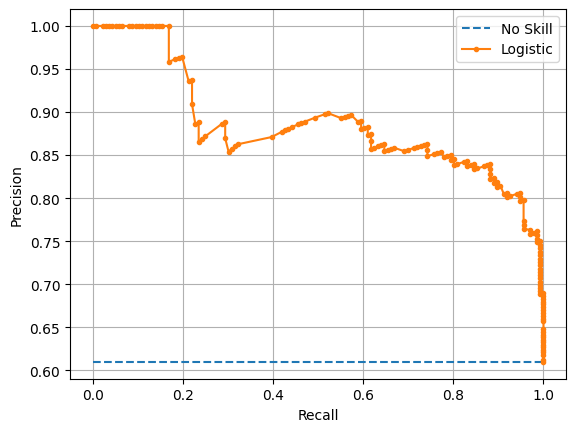

In [50]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
y_pred = log_reg.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
no_skill = len(y_test[y_test == 1]) / len(y_test)
plt.plot([0,1], [no_skill, no_skill], linestyle='--', label='No Skill')
plt.plot(recall, precision, marker='.', label='Logistic')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()

Метрики регрессии

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

y = 1 - data_new['Survived']
X = data_new.drop(labels=['Survived'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=713, test_size=0.25)
X_train.head()

,Pclass,Sex,Age,SibSp,Parch
665,2,1,32.00000,2,0
808,2,1,39.00000,0,0
768,3,1,25.14062,1,0
167,3,0,45.00000,1,4
346,2,0,40.00000,0,0


<Axes: title={'center': 'Target density'}, ylabel='Density'>

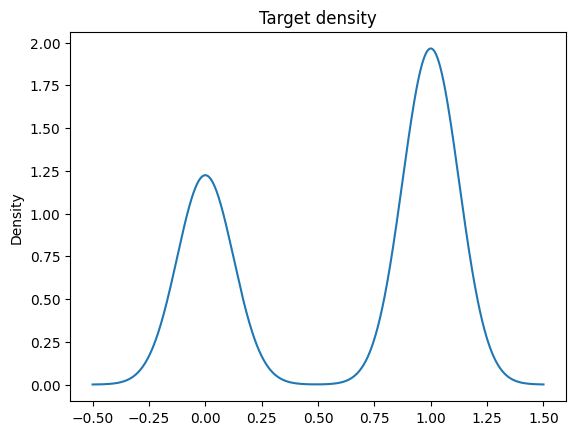

In [52]:
y.plot(kind='kde', title='Target density')

MSE & RMSE

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='median')
dummy.fit(X_train, y_train)
y_preds_dummy = dummy.predict(X_test)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds_lr = lr.predict(X_test)

In [54]:
from sklearn.metrics import mean_squared_error
import seaborn as sns
import pandas as pd
import math

print(f'MSE for Dummy Regressor: {mean_squared_error(y_test, y_preds_dummy)}')
print(f'MSE for Linear regression: {mean_squared_error(y_test, y_preds_lr)}')

print(f'RMSE for Dummy Regressor: {math.sqrt(mean_squared_error(y_test, y_preds_dummy))}')
print(f'RMSE for Linear regression: {math.sqrt(mean_squared_error(y_test, y_preds_lr))}')

MSE for Dummy Regressor: 0.3901345291479821
MSE for Linear regression: 0.14260589377328367
RMSE for Dummy Regressor: 0.6246075000734318
RMSE for Linear regression: 0.37763195544509165


In [55]:
def plot_model_results(actual, predicted, title):
  results = pd.DataFrame({'True': actual, 'Prediction': predicted})
  sns.lmplot(x='True', y='Prediction', data=results, fit_reg=False)
  d_line= np.arange(results.min().min(), results.max().max())
  plt.plot(d_line, d_line, color='red', linestyle='--')
  plt.title = title
  plt.grid()
  plt.show()

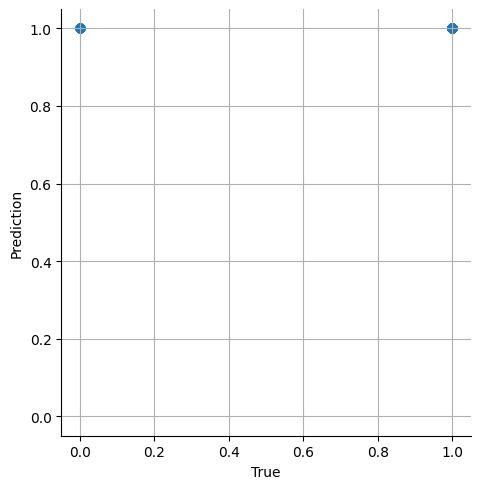

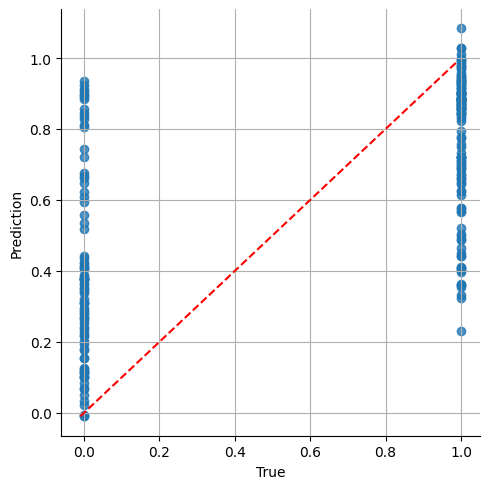

In [56]:
plot_model_results(y_test, y_preds_dummy, title='Dummy')

plot_model_results(y_test, y_preds_lr, title='Linear Regression')

MAE & MAPE

In [57]:
from sklearn.metrics import mean_absolute_error

print(f'MAE for Dummy Regressor: {mean_absolute_error(y_test, y_preds_dummy)}')
print(f'MAE for Linear regression: {mean_absolute_error(y_test, y_preds_lr)}')

from sklearn.metrics import mean_absolute_percentage_error

print(f'MAPE for Dummy Regressor: {mean_absolute_percentage_error(y_test, y_preds_dummy)}')
print(f'MAPE for Linear regression: {mean_absolute_percentage_error(y_test, y_preds_lr)}')

MAE for Dummy Regressor: 0.3901345291479821
MAE for Linear regression: 0.2922123876649759
MAPE for Dummy Regressor: 1757009720095216.0
MAPE for Linear regression: 697068504416693.6


Коэффициент детерминации

In [58]:
from sklearn.metrics import r2_score

print(f'R2 score for Dummy Regressor: {r2_score(y_test, y_preds_dummy)}')
print(f'R2 score for Linear regression: {r2_score(y_test, y_preds_lr)}')

R2 score for Dummy Regressor: -0.6397058823529413
R2 score for Linear regression: 0.4006382275649405


Кросс-валидация


In [85]:
data_new.head()
corrs = data_new.corr()
upper_tri = corrs.where(np.triu(np.ones(corrs.shape), k=1).astype(np.bool))
upper_tri

,Survived,Pclass,Sex,Age,SibSp,Parch
Survived,NaN,-0.338481,-0.543351,-0.050504,-0.035322,0.081629
Pclass,NaN,NaN,0.131900,-0.403858,0.083081,0.018443
Sex,NaN,NaN,NaN,0.080464,-0.114631,-0.245489
Age,NaN,NaN,NaN,NaN,-0.243452,-0.175799
SibSp,NaN,NaN,NaN,NaN,NaN,0.414838
Parch,NaN,NaN,NaN,NaN,NaN,NaN


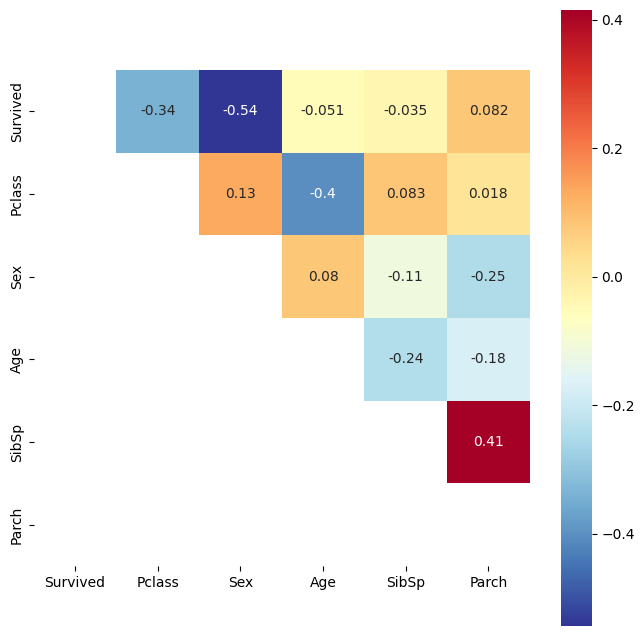

In [86]:
plt.figure(figsize=(8, 8))
sns.heatmap(upper_tri, cmap="RdYlBu_r", square=True, annot=True);

In [87]:
cols_to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
cols_to_drop

[]

In [88]:
cutted_data = data_new.drop(columns=cols_to_drop)
cutted_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,1,22.0,1,0
1,1,1,0,38.0,1,0
2,1,3,0,26.0,0,0
3,1,1,0,35.0,1,0
4,0,3,1,35.0,0,0


Train-test split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    cutted_data.drop(columns='Survived'),
    cutted_data['Survived'],
    random_state=2023,
    test_size=0.3
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds_lr = lr.predict(X_test)

print(f'RMSE: {math.sqrt(mean_squared_error(y_test, y_preds_lr))}')

RMSE: 0.3915146103113608


In [90]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch
38,3,0,18.00000,2,0
269,1,0,35.00000,0,0
141,3,0,22.00000,0,0
490,3,1,25.14062,1,0
514,3,1,24.00000,0,0


Масштабирование

<Axes: title={'center': 'Length KDE'}, ylabel='Density'>

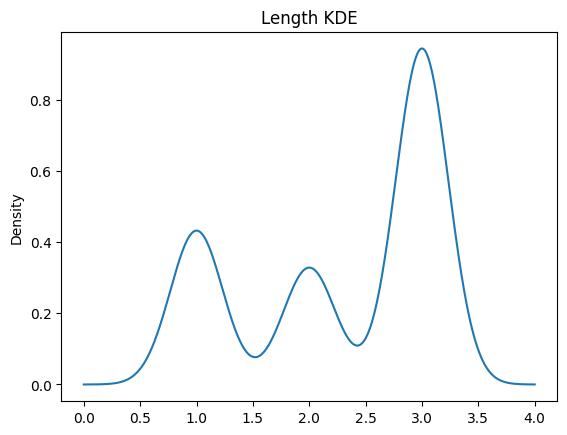

In [91]:
X_train['Pclass'].plot.kde(title='Length KDE')

<Axes: title={'center': 'Scaled Length KDE'}, ylabel='Density'>

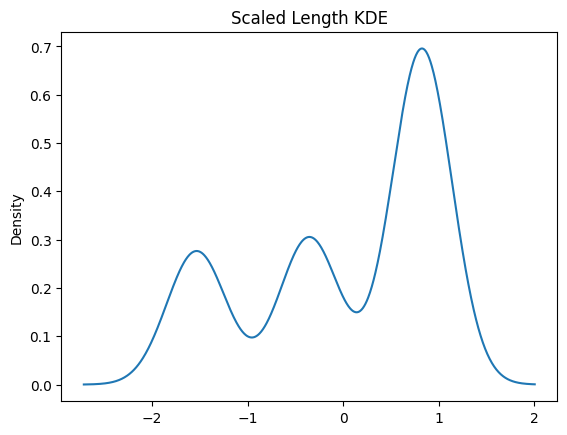

In [92]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)
X_test_scaled['Pclass'].plot.kde(title='Scaled Length KDE')

Refit

In [93]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_preds_lr = lr.predict(X_test_scaled)

print(f'RMSE: {math.sqrt(mean_squared_error(y_test, y_preds_lr))}')

RMSE: 0.39151461031136076


Интерпретация

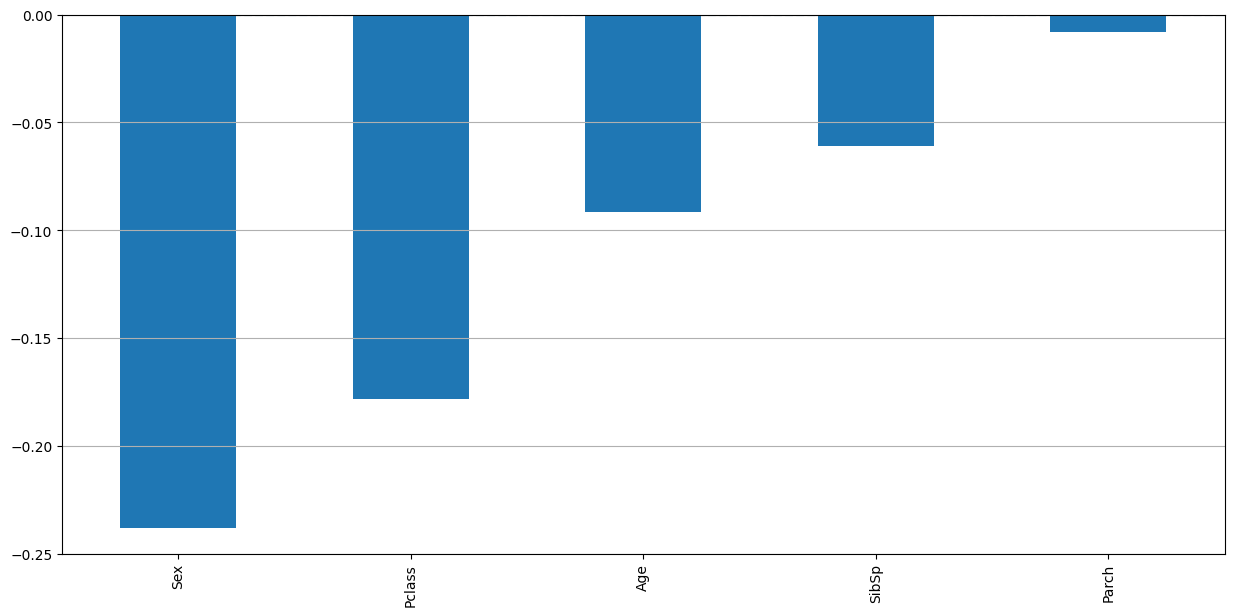

In [94]:
def plotCoefficients(model, columns):
    coefs = pd.DataFrame(model.coef_, columns)
    coefs.columns = ["coef"]
    coefs["abs"] = coefs.coef.apply(np.abs)
    coefs = coefs.sort_values(by="abs", ascending=False).drop(["abs"], axis=1)
    plt.figure(figsize=(15, 7))
    coefs.coef.plot(kind='bar')
    plt.grid(True, axis='y')
    plt.hlines(y=0, xmin=0, xmax=len(coefs), linestyles='dashed')
plotCoefficients(lr, X_train_scaled.columns)

Линейная регрессия с регуляризацией

In [95]:
from sklearn.linear_model import Ridge

X_train, X_test, y_train, y_test = train_test_split(
    cutted_data.drop(columns='Survived'),
    cutted_data['Survived'],
    random_state=2023,
    test_size=0.3
)
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)
y_preds = ridge.predict(X_test)

print(f'RMSE: {math.sqrt(mean_squared_error(y_test, y_preds_lr))}')

RMSE: 0.39151461031136076


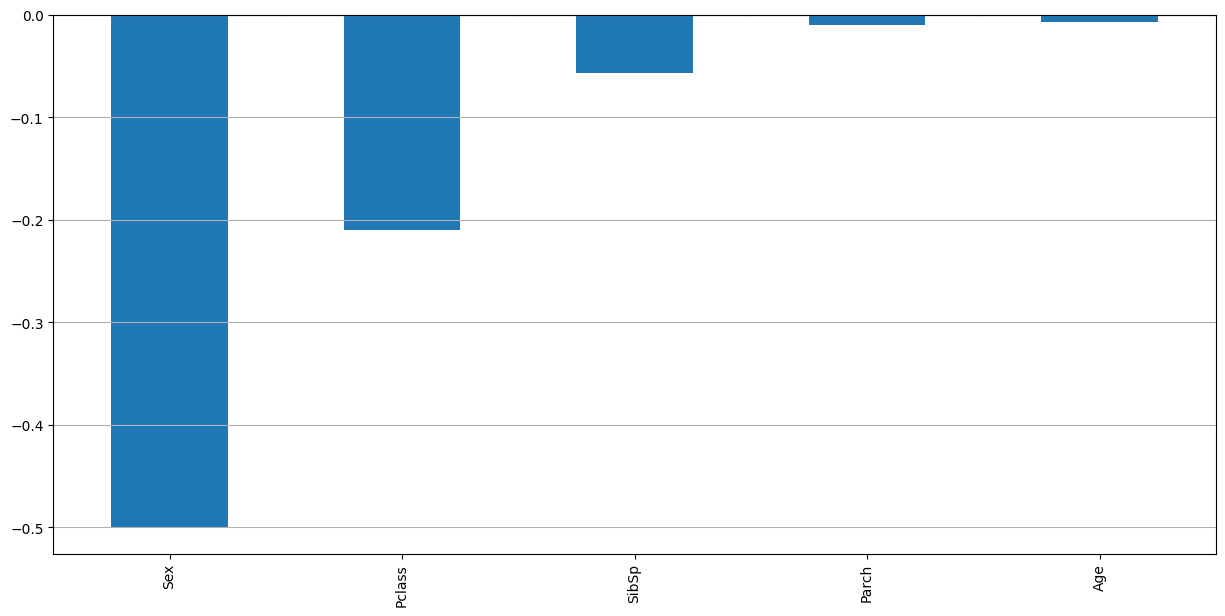

In [78]:
plotCoefficients(ridge, X_train.columns)